In [1]:
import os
import pandas as pd
import numpy as np
import boto3
from tqdm import tqdm
import datetime as dt
import pickle
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

try:
    import catboost as cb
except:
    ! pip install catboost

### Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # download file
    boto3.client('s3').download_file(str_project, str_bucket_path, str_local_path)

In [3]:
def get_tier_prop_overall(dict_tier_prop_approved, flt_approval_rate):
    df_tmp = pd.DataFrame({
        'tier': dict_tier_prop_approved.keys(),
        'prop_approved': dict_tier_prop_approved.values(),
    })
    df_tmp['prop_overall'] = df_tmp['prop_approved'] * flt_approval_rate
    df_tmp['prop_overall_cumsum'] = df_tmp['prop_overall'].cumsum()
    dict_tier_prop_overall = dict(zip(df_tmp['tier'], df_tmp['prop_overall_cumsum']))
    return dict_tier_prop_overall

In [4]:
def assign_tier(prop_rank, dict_tier_prop_overall):
    # tag tier
    if prop_rank <= dict_tier_prop_overall['A1']:
        return 'A1'
    elif prop_rank <= dict_tier_prop_overall['A']:
        return 'A'
    elif prop_rank <= dict_tier_prop_overall['B']:
        return 'B'
    elif prop_rank <= dict_tier_prop_overall['C']:
        return 'C'
    elif prop_rank <= dict_tier_prop_overall['D']:
        return 'D'
    else:
        return 'Decline'

In [5]:
def make_distribution_plot(df, str_col):
    int_n = df.shape[0]
    flt_min = df[str_col].min()
    flt_max = df[str_col].max()
    flt_mean = df[str_col].mean()
    flt_sd = df[str_col].std()
    flt_mdn = df[str_col].median()
    fig, ax = plt.subplots(figsize=(9,5))
    str_title = f"""
    Distribution of {str_col} (N = {int_n})
    Min = {flt_min:0.3f}; Max = {flt_max:0.3f}; Mean = {flt_mean:0.3f} (+/- SD = {flt_sd:0.3f}); Mdn = {flt_mdn:0.3f}
    """
    ax.set_title(str_title)
    ax.set_xlabel(str_col)
    # plot
    sns.kdeplot(list(df[str_col]), ax=ax)
    # show
    plt.show()

### Constants

In [6]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
# task
str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

# output
str_dirname_output = './output'

str_ad = 'yhat_ad_new'
str_pd = 'yhat_pd_new_logloss'
str_lgd = 'yhat_lgd_new'
str_ecnl = 'ecnl_new_logloss'

# approval rate
flt_approval_rate = 0.20
# target ecnl
flt_target_ecnl = 0.20 # 20% ECNL
# tier distribution of approvals
dict_tier_prop_approved = {
    'A1': 0.0918,
    'A': 0.1115,
    'B': 0.4321,
    'C': 0.2006,
    'D': 0.1640,
}
# get sum of proportion approved tiers to make sure it adds up to 100%
flt_sum_prop_approved = np.sum(list(dict_tier_prop_approved.values()))
if flt_sum_prop_approved != 1:
    raise ValueError('Error! The sum of the approved tier proportions must equal 1.0')
else:
    pass

Project: 20231010-gen-xii
Task: 13_payload_parsing


### Output dir

In [7]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Get data

In [8]:
# get data
str_filename = 'df_grouped.csv'
str_local_path = f'../07_analysis/output/{str_filename}'
df = pd.read_csv(str_local_path)
df

,bigaccountid__app,applicationdate__app,intopenbktype__app,ENG-loan_to_value,fltgrossmonthly__income_sum,strdealershiptrackertype__app,FICO,yhat_ad_old,yhat_ad_new,yhat_pd_old,...,ecnl_new_logloss,ecnl_new_auc,genxi_raw_pd,genxi_raw_lgd,genxi_raw_ecnl,genxi_raw_ecnl_mod,genxi_factor_pd,genxi_factor_lgd,genxi_factor_ecnl,tier
0,7272862,2023-10-24 13:08:23,13.0,1.315789,3500.0,franchise,600.0,0.272318,0.357875,0.287421,...,0.645258,0.801551,0.161586,0.423359,0.068409,0.100966,0.161586,0.423359,0.153468,B
1,7464573,2024-01-02 16:11:37,NaN,1.440000,5000.0,franchise,544.0,0.439553,0.612798,0.600141,...,0.525708,0.472669,0.305147,0.453501,0.138384,0.237805,0.311181,0.453381,0.369486,Decline
2,7506291,2024-01-20 10:59:46,13.0,0.678571,3500.0,franchise,573.0,0.121979,0.215302,0.169208,...,0.345682,0.278693,0.063494,0.384980,0.024444,0.014991,0.063494,0.384980,0.022786,A1
3,7517896,2024-01-25 10:58:56,7.0,1.545455,3500.0,franchise,528.0,0.109013,0.165463,0.447872,...,0.281287,0.496253,0.096526,0.476634,0.046008,0.057159,0.096526,0.476634,0.086882,A
4,7550886,2024-02-07 08:17:30,13.0,1.407407,6000.0,independent,506.0,0.155811,0.262346,0.341895,...,0.378869,0.414683,0.091912,0.417550,0.038378,0.042239,0.091912,0.417550,0.064203,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
327,7629946,2024-03-04 09:28:00,NaN,1.185185,4500.0,independent,421.0,0.384362,0.623494,0.740635,...,0.760091,0.606782,0.316360,0.500376,0.158299,0.276748,0.316360,0.500376,0.420657,Decline
328,7629949,2024-03-04 09:28:20,NaN,1.153846,4000.0,franchise,559.0,0.331976,0.499637,0.329202,...,0.474164,0.513649,0.201420,0.506216,0.101962,0.166579,0.201420,0.506216,0.253200,C
329,7629951,2024-03-04 09:29:17,NaN,1.292683,2500.0,franchise,552.0,0.265567,0.423616,0.368439,...,0.168518,0.306388,0.147073,0.400683,0.058930,0.082429,0.155006,0.411678,0.125292,B
330,7629952,2024-03-04 09:29:30,NaN,1.161290,4000.0,independent,528.0,0.560871,0.700855,0.680143,...,0.899190,0.884792,0.424180,0.538251,0.228316,0.413668,0.424180,0.538251,0.628775,Decline


### Convert approved tier proportions to overall tier proportions

In [9]:
dict_tier_prop_overall = get_tier_prop_overall(
    dict_tier_prop_approved=dict_tier_prop_approved, 
    flt_approval_rate=flt_approval_rate,
)
dict_tier_prop_overall

{'A1': 0.01836, 'A': 0.04066, 'B': 0.12708, 'C': 0.16720000000000002, 'D': 0.2}

### Assign tiers

In [10]:
# sort ascending
df.sort_values(by=str_ecnl, ascending=True, inplace=True)
df['rank'] = list(range(1, df.shape[0]+1))
df['prop_rank'] = df['rank'] / df.shape[0]
df.drop('rank', axis=1, inplace=True)

# assign tier
df['tier'] = df['prop_rank'].apply(
    lambda x: assign_tier(
        prop_rank=x, 
        dict_tier_prop_overall=dict_tier_prop_overall,
    ),
)

# show
df

,bigaccountid__app,applicationdate__app,intopenbktype__app,ENG-loan_to_value,fltgrossmonthly__income_sum,strdealershiptrackertype__app,FICO,yhat_ad_old,yhat_ad_new,yhat_pd_old,...,ecnl_new_auc,genxi_raw_pd,genxi_raw_lgd,genxi_raw_ecnl,genxi_raw_ecnl_mod,genxi_factor_pd,genxi_factor_lgd,genxi_factor_ecnl,tier,prop_rank
125,7629554,2024-03-03 18:59:58,NaN,0.625000,6000.0,franchise,702.0,0.133077,0.263856,0.067995,...,0.094368,0.056754,0.349088,0.019812,0.005933,0.056754,0.349088,0.062218,A1,0.003012
28,7598842,2024-02-23 12:05:07,NaN,0.678571,3000.0,independent,578.5,0.188731,0.343839,0.115886,...,0.448461,0.116589,0.447633,0.052189,0.069247,0.104501,0.465876,0.110691,A1,0.006024
122,7629550,2024-03-03 18:47:50,NaN,1.178571,7500.0,franchise,423.0,0.263060,0.399910,0.170507,...,0.226903,0.124639,0.366288,0.045654,0.056468,0.140597,0.391854,0.113889,A1,0.009036
273,7629844,2024-03-04 09:06:16,NaN,0.925926,2500.0,franchise,646.5,0.185911,0.308170,0.054454,...,0.134802,0.047620,0.322381,0.015352,-0.002789,0.054072,0.302667,0.053200,A1,0.012048
63,7622345,2024-03-01 09:27:03,13.0,1.073171,5000.0,independent,541.0,0.163518,0.291974,0.213272,...,0.148474,0.059096,0.374329,0.022121,0.010449,0.059096,0.374329,0.074402,A1,0.015060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,7629693,2024-03-04 08:26:31,NaN,1.131579,4500.0,franchise,518.0,0.428252,0.637573,0.490660,...,0.816985,0.314321,0.494155,0.155323,0.270929,0.314321,0.494155,0.411812,Decline,0.987952
323,7629939,2024-03-04 09:26:13,NaN,1.136364,4000.0,independent,406.0,0.343643,0.698121,0.318945,...,0.888712,0.219532,0.374500,0.082215,0.127963,0.219532,0.374500,0.194504,Decline,0.990964
253,7629807,2024-03-04 08:55:39,NaN,1.296296,3500.0,independent,477.0,0.606615,0.746001,0.649499,...,0.919900,0.363547,0.546582,0.198708,0.355770,0.363547,0.546582,0.540770,Decline,0.993976
141,7629581,2024-03-04 05:57:28,NaN,1.285714,6000.0,independent,506.0,0.498406,0.639636,0.658302,...,0.814207,0.393700,0.504497,0.198620,0.355598,0.393700,0.504497,0.540509,Decline,0.996988


### Get tier thresholds

In [11]:
df_tmp = df[df['tier'] != 'Decline'].groupby(by='tier', as_index=False).agg({
    str_ecnl: 'max',
})
df_tmp

,tier,ecnl_new_logloss
0,A,0.153816
1,A1,0.092130
2,B,0.216952
3,C,0.228800
4,D,0.247343


In [12]:
# thresholds
df_tmp = df[df['tier'] != 'Decline'].groupby(by='tier', as_index=False).agg({
    str_ecnl: 'max',
})

# write to csv
str_filename = 'df_tiers.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_csv(str_local_path, index=False)

# make dict
dict_ecnl_mod_thresh = dict(zip(df_tmp['tier'], df_tmp[str_ecnl]))
print('Tier thresholds:')
dict_ecnl_mod_thresh

Tier thresholds:


{'A': 0.1538164415360458,
 'A1': 0.0921302371584857,
 'B': 0.2169516454144856,
 'C': 0.2288003753691115,
 'D': 0.2473432051128705}

### Tier distributions overall

In [13]:
# tier distributions overall
flt_mean = df[str_ecnl].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
ser_freq = df['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Tier','Proportion Overall']
df_freq

Mean ECNL: 0.4300


,Tier,Proportion Overall
0,Decline,0.801205
1,B,0.087349
2,C,0.039157
3,D,0.033133
4,A,0.021084
5,A1,0.018072


### Tier distributions of those approved by pricing models

In [14]:
# tier distributions approved by pricing
df_tmp = df[df['tier'] != 'Decline'].copy()
flt_mean = df_tmp[str_ecnl].mean()
print(f'Mean ECNL: {flt_mean:0.4f}')
ser_freq = df_tmp['tier'].value_counts(normalize=True)
df_freq = ser_freq.reset_index()
df_freq.columns = ['Tier','Proportion Pricing Approved']
df_freq

Mean ECNL: 0.1852


,Tier,Proportion Pricing Approved
0,B,0.439394
1,C,0.196970
2,D,0.166667
3,A,0.106061
4,A1,0.090909


### Columns for distribution plots

In [15]:
list_str_col = [
    str_ad,
    str_pd,
    str_lgd,
    str_ecnl,
]

### Distribution plots

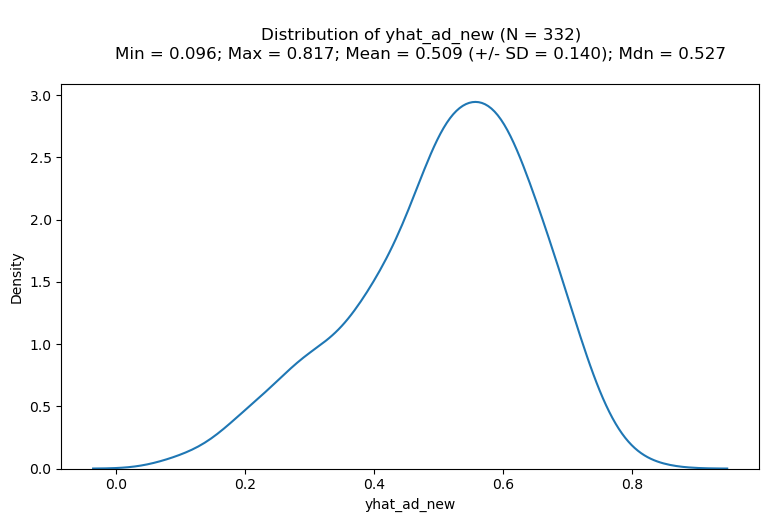

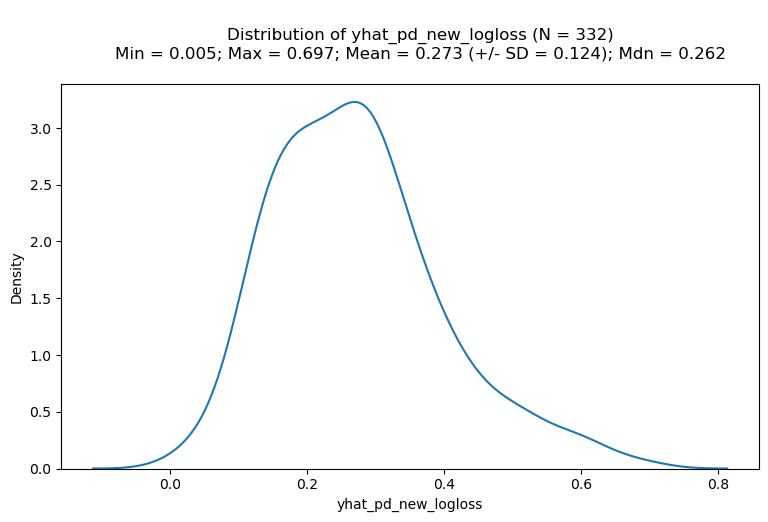

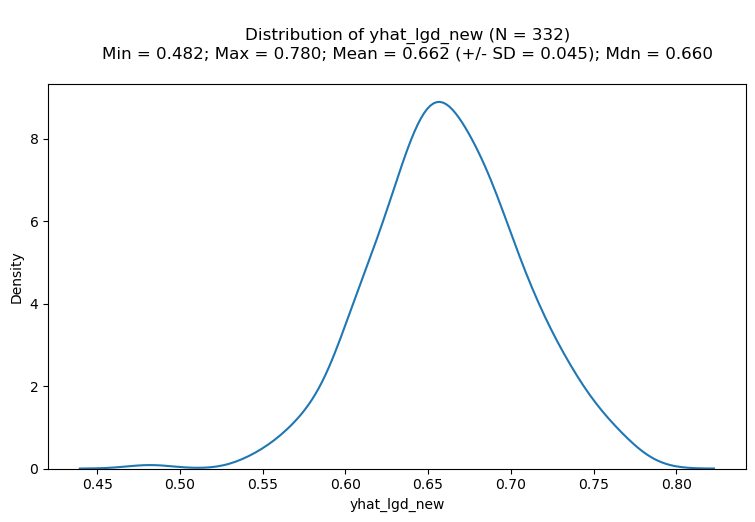

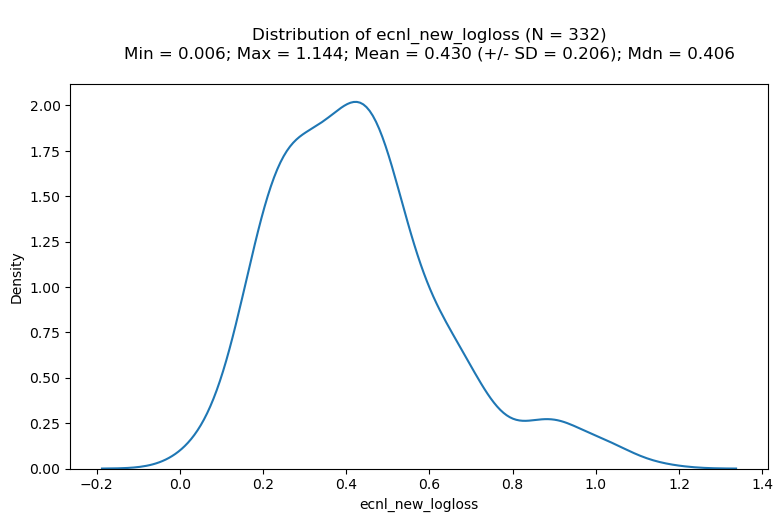

In [16]:
for str_col in list_str_col:
    make_distribution_plot(
        df=df,
        str_col=str_col,
    )

### Distribution plots of approvals

In [17]:
df_tmp = df[df['tier'] != 'Decline'].copy()
df_tmp

,bigaccountid__app,applicationdate__app,intopenbktype__app,ENG-loan_to_value,fltgrossmonthly__income_sum,strdealershiptrackertype__app,FICO,yhat_ad_old,yhat_ad_new,yhat_pd_old,...,ecnl_new_auc,genxi_raw_pd,genxi_raw_lgd,genxi_raw_ecnl,genxi_raw_ecnl_mod,genxi_factor_pd,genxi_factor_lgd,genxi_factor_ecnl,tier,prop_rank
125,7629554,2024-03-03 18:59:58,NaN,0.625000,6000.0,franchise,702.0,0.133077,0.263856,0.067995,...,0.094368,0.056754,0.349088,0.019812,0.005933,0.056754,0.349088,0.062218,A1,0.003012
28,7598842,2024-02-23 12:05:07,NaN,0.678571,3000.0,independent,578.5,0.188731,0.343839,0.115886,...,0.448461,0.116589,0.447633,0.052189,0.069247,0.104501,0.465876,0.110691,A1,0.006024
122,7629550,2024-03-03 18:47:50,NaN,1.178571,7500.0,franchise,423.0,0.263060,0.399910,0.170507,...,0.226903,0.124639,0.366288,0.045654,0.056468,0.140597,0.391854,0.113889,A1,0.009036
273,7629844,2024-03-04 09:06:16,NaN,0.925926,2500.0,franchise,646.5,0.185911,0.308170,0.054454,...,0.134802,0.047620,0.322381,0.015352,-0.002789,0.054072,0.302667,0.053200,A1,0.012048
63,7622345,2024-03-01 09:27:03,13.0,1.073171,5000.0,independent,541.0,0.163518,0.291974,0.213272,...,0.148474,0.059096,0.374329,0.022121,0.010449,0.059096,0.374329,0.074402,A1,0.015060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29,7601311,2024-02-23 17:15:53,NaN,1.366667,5500.0,franchise,521.5,0.334638,0.507576,0.233456,...,0.207408,0.137863,0.430014,0.059283,0.083120,0.120286,0.433684,0.126342,D,0.186747
230,7629761,2024-03-04 08:43:42,NaN,1.233333,3500.0,franchise,491.0,0.417470,0.609698,0.411395,...,0.362856,0.325942,0.473645,0.154381,0.269086,0.325942,0.473645,0.409011,D,0.189759
22,7590857,2024-02-21 15:36:31,NaN,1.155556,5500.0,franchise,513.0,0.254440,0.457363,0.214356,...,0.274321,0.147302,0.320677,0.047236,0.059562,0.147302,0.320677,0.130054,D,0.192771
174,7629654,2024-03-04 08:10:27,NaN,1.068966,3500.0,franchise,564.0,0.301847,0.517341,0.364070,...,0.436306,0.190216,0.475373,0.090424,0.144016,0.190216,0.475373,0.218904,D,0.195783


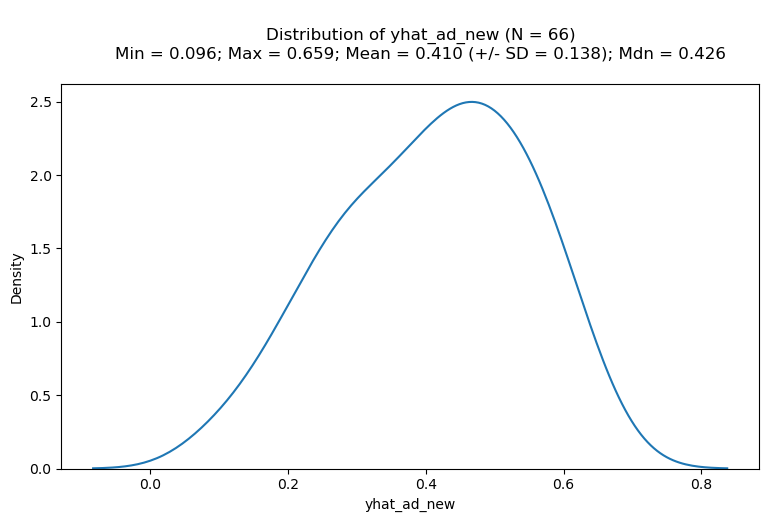

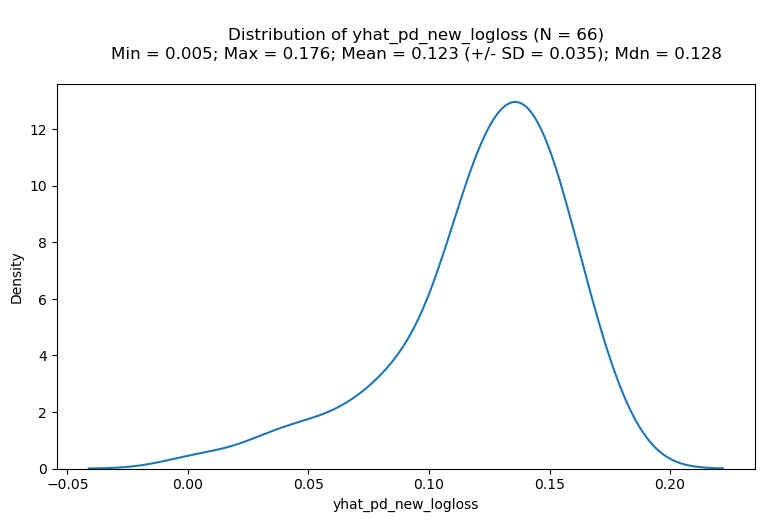

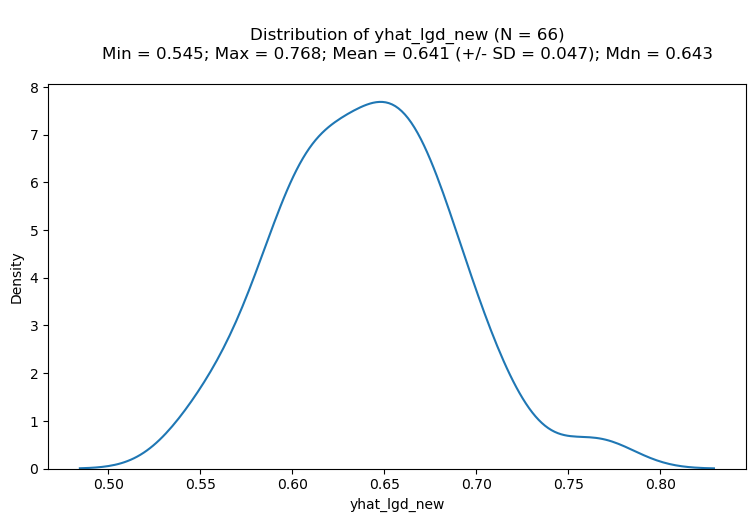

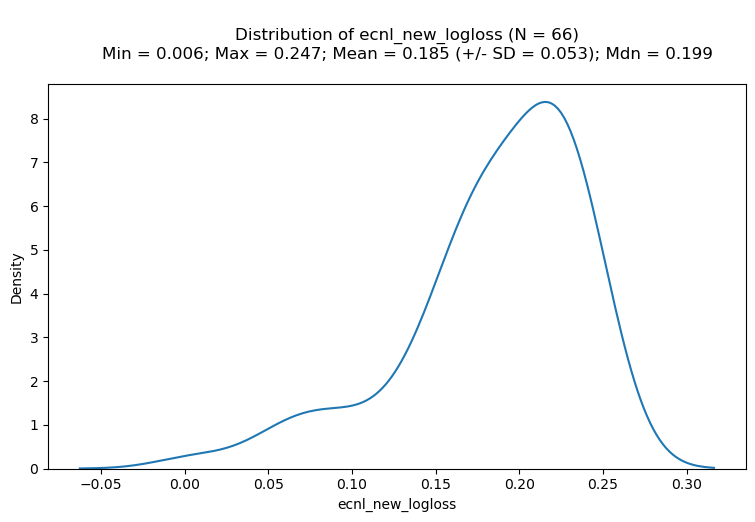

In [18]:
for str_col in list_str_col:
    make_distribution_plot(
        df=df_tmp,
        str_col=str_col,
    )

### Distribution plots of declines

In [19]:
df_tmp = df[df['tier'] == 'Decline'].copy()
df_tmp

,bigaccountid__app,applicationdate__app,intopenbktype__app,ENG-loan_to_value,fltgrossmonthly__income_sum,strdealershiptrackertype__app,FICO,yhat_ad_old,yhat_ad_new,yhat_pd_old,...,ecnl_new_auc,genxi_raw_pd,genxi_raw_lgd,genxi_raw_ecnl,genxi_raw_ecnl_mod,genxi_factor_pd,genxi_factor_lgd,genxi_factor_ecnl,tier,prop_rank
115,7629539,2024-03-03 18:15:35,NaN,1.169492,4000.0,independent,718.0,0.176702,0.324570,0.117374,...,0.214007,0.192830,0.412233,0.079491,0.122637,0.169304,0.418012,0.186408,Decline,0.201807
88,7629032,2024-03-02 17:59:00,NaN,1.275862,6000.0,independent,595.0,0.263477,0.408237,0.138934,...,0.290696,0.151918,0.402319,0.061119,0.086711,0.151918,0.402319,0.131801,Decline,0.204819
276,7629852,2024-03-04 09:07:35,NaN,1.068182,3500.0,franchise,474.0,0.289868,0.563835,0.183038,...,0.321863,0.289611,0.389316,0.112750,0.187676,0.289611,0.389316,0.285268,Decline,0.207831
19,7586743,2024-02-20 13:41:28,NaN,1.428571,4500.0,franchise,524.0,0.101776,0.194333,0.222724,...,0.264025,0.095437,0.408035,0.038942,0.043342,0.095437,0.408035,0.105400,Decline,0.210843
151,7629606,2024-03-04 07:36:06,NaN,1.247191,7000.0,franchise,536.0,0.214292,0.402711,0.174641,...,0.232686,0.197521,0.367391,0.072567,0.109097,0.194229,0.359919,0.157919,Decline,0.213855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,7629693,2024-03-04 08:26:31,NaN,1.131579,4500.0,franchise,518.0,0.428252,0.637573,0.490660,...,0.816985,0.314321,0.494155,0.155323,0.270929,0.314321,0.494155,0.411812,Decline,0.987952
323,7629939,2024-03-04 09:26:13,NaN,1.136364,4000.0,independent,406.0,0.343643,0.698121,0.318945,...,0.888712,0.219532,0.374500,0.082215,0.127963,0.219532,0.374500,0.194504,Decline,0.990964
253,7629807,2024-03-04 08:55:39,NaN,1.296296,3500.0,independent,477.0,0.606615,0.746001,0.649499,...,0.919900,0.363547,0.546582,0.198708,0.355770,0.363547,0.546582,0.540770,Decline,0.993976
141,7629581,2024-03-04 05:57:28,NaN,1.285714,6000.0,independent,506.0,0.498406,0.639636,0.658302,...,0.814207,0.393700,0.504497,0.198620,0.355598,0.393700,0.504497,0.540509,Decline,0.996988


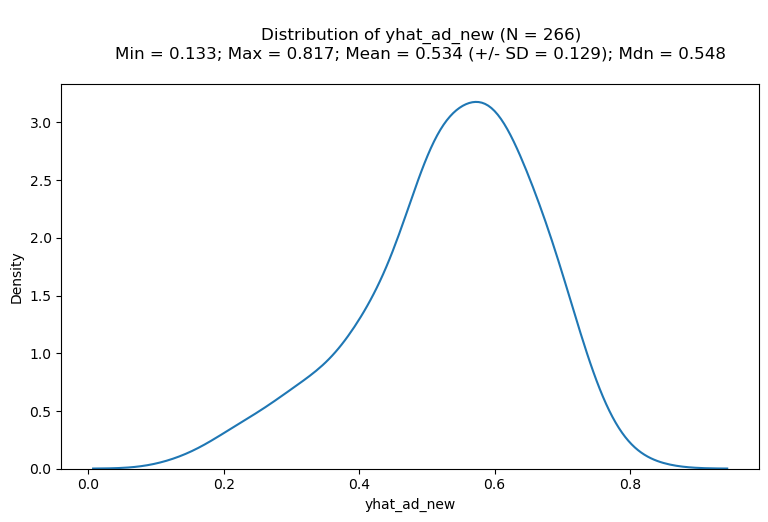

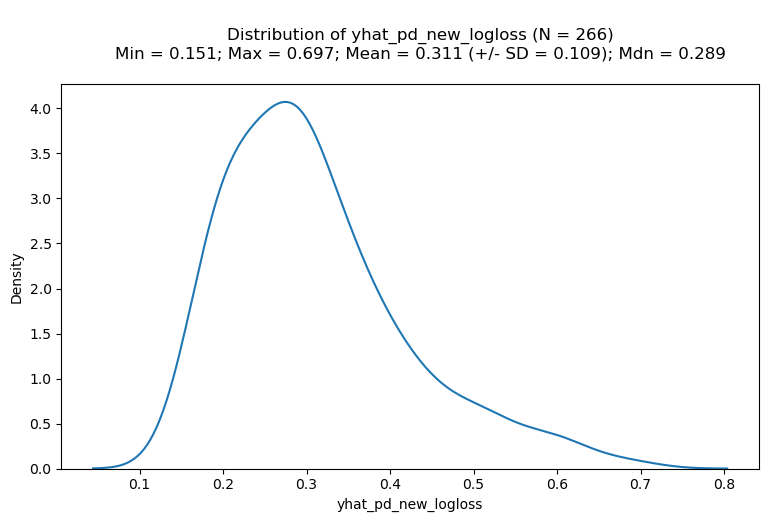

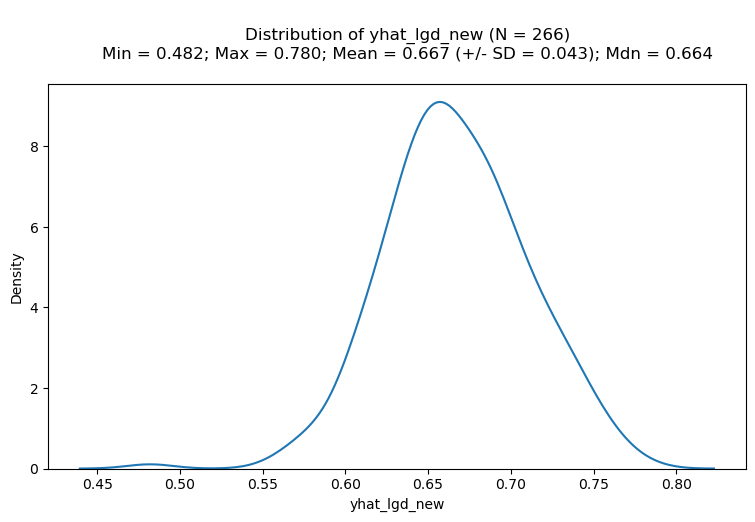

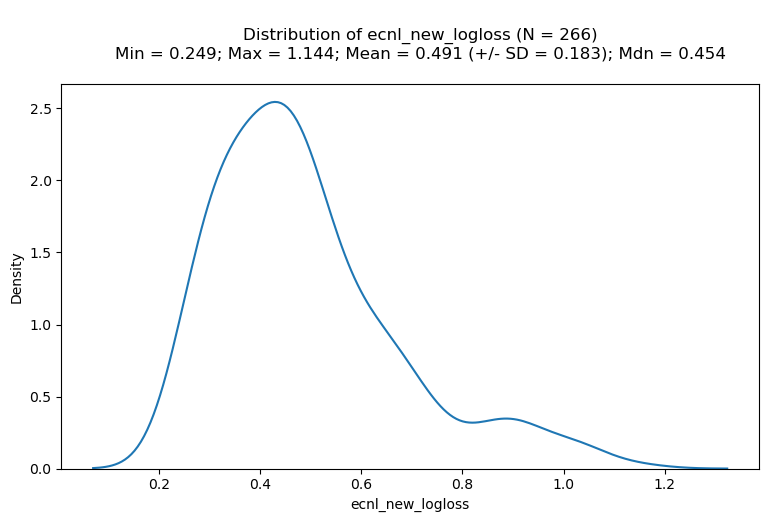

In [20]:
for str_col in list_str_col:
    make_distribution_plot(
        df=df_tmp,
        str_col=str_col,
    )

### Plot

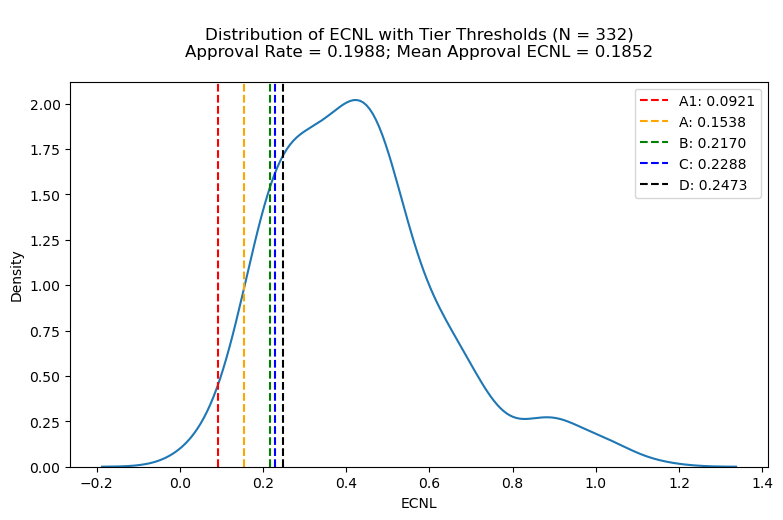

In [21]:
# get approval rate
df_tmp = df[df['tier'] != 'Decline'].copy()
flt_prop_approval = df_tmp.shape[0] / df.shape[0]
# mean ecnl of approvals
flt_mean_ecnl = df_tmp[str_ecnl].mean()
# plot
list_str_tier = [
    'A1',
    'A',
    'B',
    'C',
    'D',
]
list_str_colors = [
    'red',
    'orange',
    'green',
    'blue',
    'black',
]
int_n = df.shape[0]
fig, ax = plt.subplots(figsize=(9,5))
str_title = f"""
Distribution of ECNL with Tier Thresholds (N = {int_n})
Approval Rate = {flt_prop_approval:0.4f}; Mean Approval ECNL = {flt_mean_ecnl:0.4f}
"""
ax.set_title(str_title)
ax.set_xlabel('ECNL')
# plot
sns.kdeplot(list(df[str_ecnl]), ax=ax)
# add threshold lines
for a, str_tier in enumerate(list_str_tier):
    flt_thresh = dict_ecnl_mod_thresh[str_tier]
    ax.axvline(flt_thresh, linestyle='--', color=list_str_colors[a], label=f'{str_tier}: {flt_thresh:0.4f}')
# legend
plt.legend()
# show
plt.show()